In [1]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"

Mounted at /content/drive
'apple fruit'	'chickoo fruit'  'mango fruit'
'banana fruit'	'grapes fruit'	 'orange fruit'
'cherry fruit'	'kiwi fruit'	 'strawberry fruit'


In [2]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3

CLASS_NAMES = [
    "apple fruit",
    "banana fruit",
    "cherry fruit",
    "chickoo fruit",
    "grapes fruit",
    "kiwi fruit",
    "mango fruit",
    "orange fruit",
    "strawberry fruit"
]

NUM_CLASSES = len(CLASS_NAMES)

print("Number of Classes:", NUM_CLASSES)

Number of Classes: 9


In [3]:
def read_decode(filename,resize_dims):
  img_bytes = tf.io.read_file(filename)
  img = tf.image.decode_jpeg(img_bytes,channels=IMG_CHANNELS)
  img = tf.image.convert_image_dtype(img,tf.float32)
  img = tf.image.resize(img,resize_dims)
  return img

In [4]:
def parse_csvline(csv_line):
   record_default = ["",""]
   filename,label_string = tf.io.decode_csv(csv_line,record_default)
   img = read_decode(filename,[IMG_HEIGHT, IMG_WIDTH])

   label =tf.argmax(tf.math.equal(CLASS_NAMES,label_string))
   return img, label

In [5]:
import os
import math
import random
import pathlib

random.seed(42)

# Dataset Path
data_dir = pathlib.Path(
    "/content/drive/MyDrive/Colab Notebooks/Linear_Nerual_Network/dataset/images"
)

CLASS_NAMES_PY = [
    'apple fruit',
    'banana fruit',
    'cherry fruit',
    'chickoo fruit',
    'grapes fruit',
    'kiwi fruit',
    'mango fruit',
    'orange fruit',
    'strawberry fruit'
]

TRAIN_CSV = '/tmp/train_set.csv'
EVAL_CSV  = '/tmp/eval_set.csv'

train_rows = []
eval_rows = []

for cls in CLASS_NAMES_PY:
    cls_dir = data_dir / cls

    images = sorted(str(p) for p in cls_dir.glob('*.jpg'))

    random.shuffle(images)

    split = math.ceil(len(images) * 0.8)

    train_rows += [(p, cls) for p in images[:split]]
    eval_rows += [(p, cls) for p in images[split:]]

random.shuffle(train_rows)
random.shuffle(eval_rows)

with open(TRAIN_CSV, 'w') as f:
    for path, label in train_rows:
        f.write(f"{path},{label}\n")

with open(EVAL_CSV, 'w') as f:
    for path, label in eval_rows:
        f.write(f"{path},{label}\n")

print("Train samples:", len(train_rows))
print("Eval samples :", len(eval_rows))



Train samples: 255
Eval samples : 60


In [6]:
train_dataset = (
    tf.data.TextLineDataset(TRAIN_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

eval_dataset = (
    tf.data.TextLineDataset(EVAL_CSV)
    .map(parse_csvline, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print('Datasets ready.')

Datasets ready.


In [7]:
print("Classes:", CLASS_NAMES)
print("Number of Classes:", len(CLASS_NAMES))




print("Height:", IMG_HEIGHT)
print("Width:", IMG_WIDTH)
print("Channels:", IMG_CHANNELS)

Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Number of Classes: 9
Height: 224
Width: 224
Channels: 3


In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 360 files belonging to 9 classes.
Using 288 files for training.
Found 360 files belonging to 9 classes.
Using 72 files for validation.


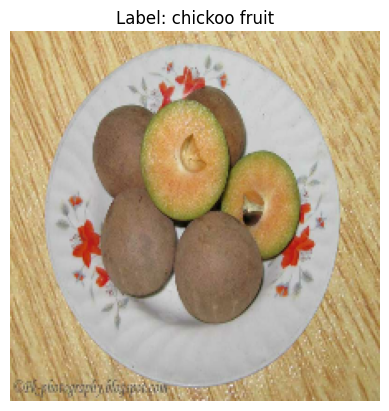

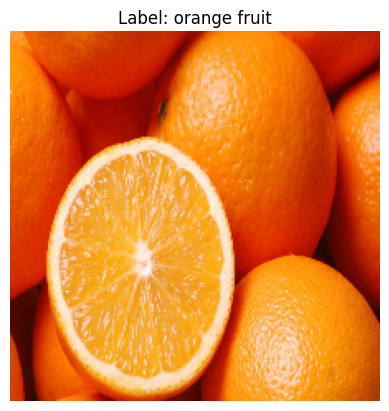

In [9]:
import matplotlib.pyplot as plt

for image_batch, label_batch in train_dataset.take(2):
    # Take the first image from the batch
    first_image = image_batch[0]
    first_label = label_batch[0]

    # Convert tensor to numpy array
    plt.imshow(first_image.numpy())
    plt.title(f"Label: {CLASS_NAMES[first_label]}")
    plt.axis('off')
    plt.show()

In [10]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

model = keras.Sequential([

    base_model,

    keras.layers.GlobalAveragePooling2D(),

    keras.layers.Dropout(0.3),

    keras.layers.Dense(
        9,
        activation="softmax"
    )

])

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Summary
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,061,100 (15.49 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 151s 13s/step - accuracy: 0.0972 - loss: 2.3709 - val_accuracy: 0.1667 - val_loss: 2.2207
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 994ms/step - accuracy: 0.1215 - loss: 2.3051 - val_accuracy: 0.2083 - val_loss: 2.1528
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.1493 - loss: 2.2110 - val_accuracy: 0.2500 - val_loss: 2.0876
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 850ms/step - accuracy: 0.2361 - loss: 2.1110 - val_accuracy: 0.3056 - val_loss: 2.0228
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 821ms/step - accuracy: 0.2743 - loss: 2.0534 - val_accuracy: 0.3472 - val_loss: 1.9614
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3576 - loss: 1.9508 - val_accuracy: 0.3889 - val_loss: 1.9024
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 831ms/step - accuracy: 0.3750 - loss: 1.9079 - val_accuracy: 0.4583 - val_loss: 1.8451
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 840ms/step - accuracy: 0.3924 - loss: 1.8617 - val_accuracy: 0.4583 - val_loss: 1

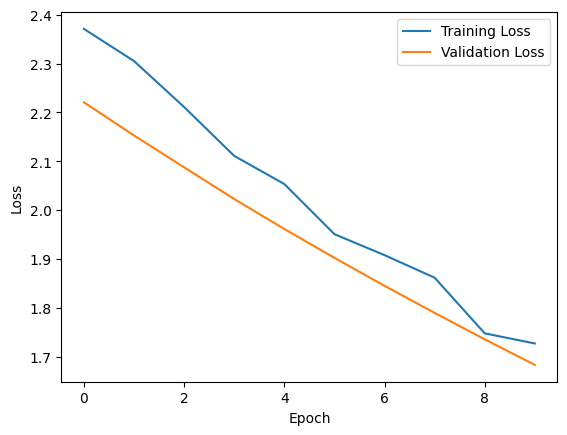

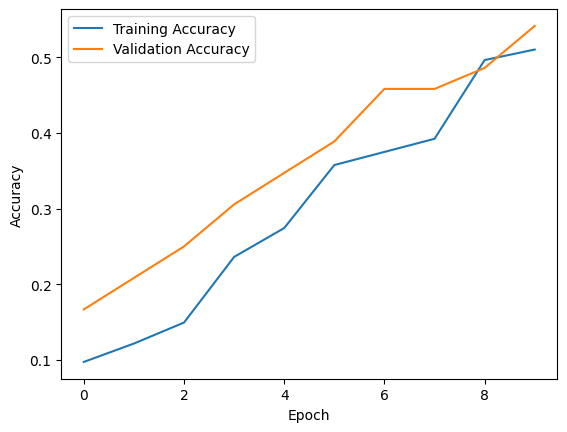

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


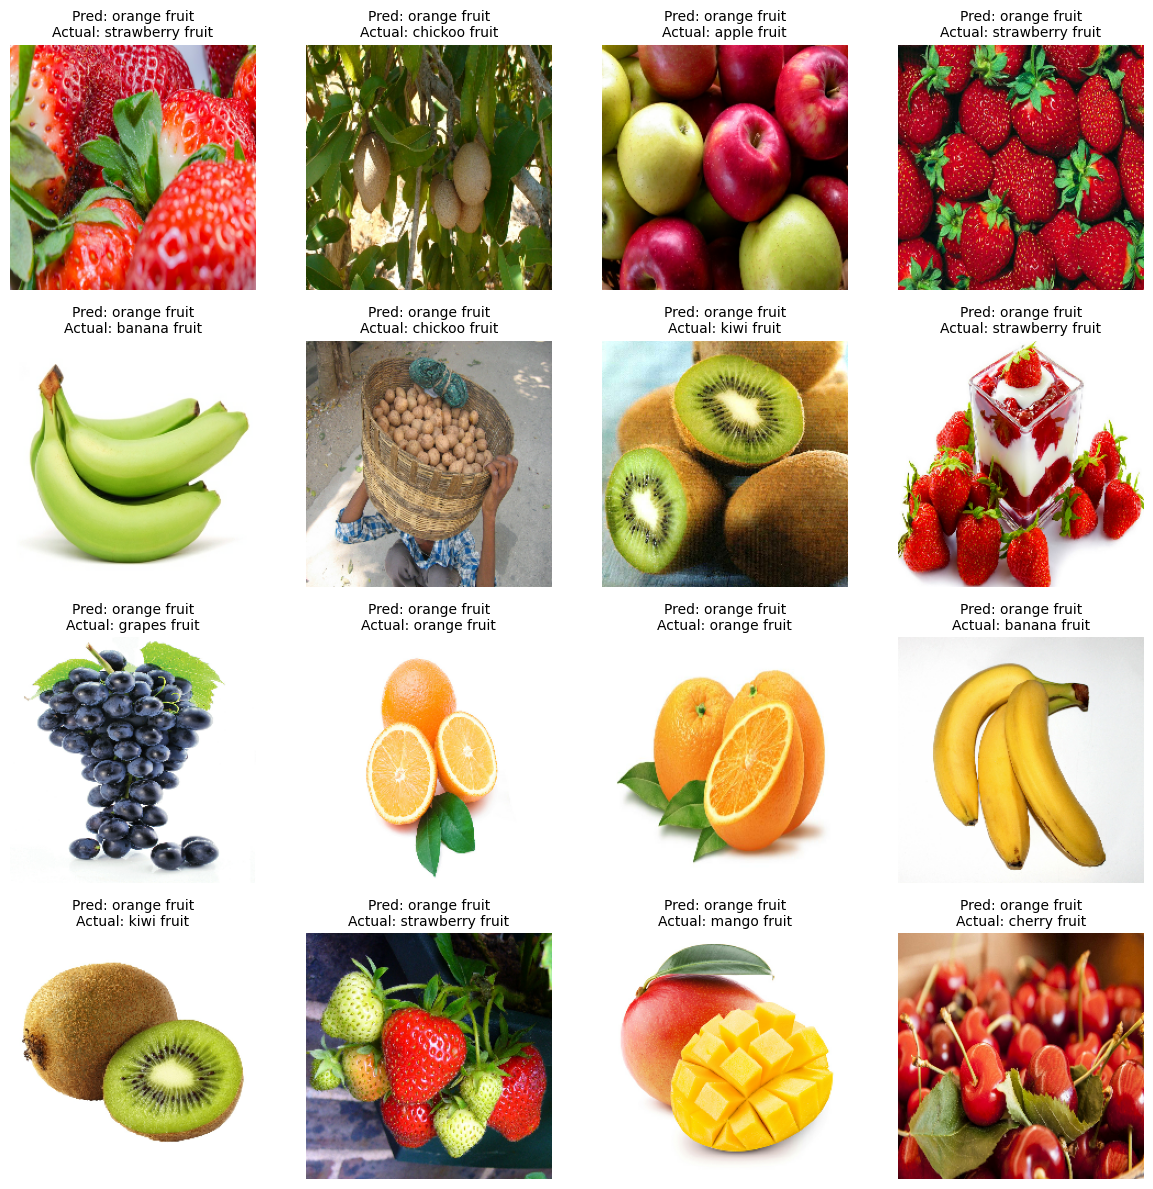

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import math

for images, labels in eval_dataset.take(1):

    batch_predictions = model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    num_images = images.shape[0]

    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)


        plt.imshow(images[i].numpy())
        plt.axis('off')

        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10)

    plt.tight_layout()
    plt.show()